In [1]:
# Figure 2 — Population geometry
# Step 1: Construct the subject-level population feature matrix

from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().parent

TABLES_DIR = PROJECT_ROOT / "tables1"
DATA_DIR = PROJECT_ROOT / "data" / "raw"

SUBJECT = "YFF"
TASK = "arithmetic"

In [3]:
results = pd.read_csv(
    TABLES_DIR / f"figure1M_{SUBJECT}_permutation.csv"
)

print("Shape:", results.shape)
display(results.head())

Shape: (37, 16)


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFF,9,ent,0.100917,0.165138,180,0.2,109,7,0.106376,0.646766,False,0.105092,0.059701,False,12.667940
1,YFF,10,hpc,0.091743,0.155963,90,0.2,109,7,0.106881,0.731343,False,0.109266,0.094527,False,11.077304
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
4,YFF,13,hpc,0.146789,0.155963,100,0.8,109,7,0.104771,0.159204,False,0.113257,0.139303,False,11.468347


In [4]:
selected = results.loc[
    results["TC_p"] <= 0.125
].copy()

print(f"Total neurons: {len(results)}")
print(f"Neurons with TC_p <= 0.125: {len(selected)}")

display(
    selected[
        [
            "neuron",
            "region",
            "TC_accuracy",
            "best_bin_ms",
            "best_gamma",
            "TC_p",
        ]
    ]
)

Total neurons: 37
Neurons with TC_p <= 0.125: 20


,neuron,region,TC_accuracy,best_bin_ms,best_gamma,TC_p
0,9,ent,0.165138,180,0.2,0.059701
1,10,hpc,0.155963,90,0.2,0.094527
2,11,hpc,0.201835,100,0.5,0.019900
3,12,hpc,0.174312,300,0.5,0.049751
5,14,hpc,0.192661,100,0.2,0.029851
6,15,hpc,0.165138,75,0.5,0.089552
8,17,hpc,0.165138,150,0.2,0.079602
11,29,hpc,0.183486,180,0.2,0.034826
13,31,hpc,0.192661,100,0.5,0.024876
15,33,hpc,0.174312,90,0.8,0.054726


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

SRC_DIR = PROJECT_ROOT / "src"

print("Files in src/:")
for p in sorted(SRC_DIR.glob("*.py")):
    print(" -", p.name)

Files in src/:
 - __init__.py
 - firing_rate_tuning.py
 - number_decoding_analysis.py
 - paired_neuron_analysis.py
 - paired_neuron_analysis_fast.py
 - single_neuron_plots.py


In [9]:
import src.number_decoding_analysis as nda

[name for name in dir(nda) if not name.startswith("_")]

['ARITH_DURATION_MS',
 'ARITH_END_MS',
 'ARITH_START_MS',
 'BIN_SIZES_MS',
 'CHANCE_LEVEL',
 'Ellipse',
 'GAMMAS',
 'LinearDiscriminantAnalysis',
 'N_CLASSES',
 'Path',
 'StratifiedKFold',
 'analyze_neuron',
 'analyze_number_decoding',
 'cv_lda_accuracy',
 'cv_lda_per_number_accuracy',
 'fit_temporal_components',
 'make_firing_rate_features',
 'make_temporal_features',
 'np',
 'pd',
 'permutation_test',
 'permutation_test_decoding',
 'plot_figure_g',
 'plot_figure_h',
 'plot_null_distribution',
 'plt',
 'temporal_grid_search']

In [10]:
import inspect
import src.number_decoding_analysis as nda

print(inspect.getsource(nda.make_temporal_features))

def make_temporal_features(
    presentations,
    spike_times,
    bin_size,
    window_start=ARITH_START_MS,
    window_end=ARITH_END_MS,
):
    """
    Convert each operand presentation into binned spike counts.

    Example
    -------
    150-ms bins over 50-950 ms:

        [50,200)
        [200,350)
        ...
        [800,950)

    giving six temporal features per presentation.
    """

    bin_edges = np.arange(
        window_start,
        window_end + bin_size,
        bin_size,
        dtype=float,
    )

    # protect against floating/integer edge issues
    bin_edges[-1] = window_end

    X = []
    y = []

    for _, row in presentations.iterrows():

        onset = float(row["onset"])
        number = int(row["number"])

        relative_spikes = spike_times - onset

        counts, _ = np.histogram(
            relative_spikes,
            bins=bin_edges,
        )

        X.append(counts)
        y.append(number)

    return (
        np.asarray(X, dtype=float),
  

In [11]:
print(inspect.signature(nda.make_temporal_features))

(presentations, spike_times, bin_size, window_start=50, window_end=950)


In [12]:
import inspect
import src.number_decoding_analysis as nda



In [13]:
print(inspect.getsource(nda.analyze_number_decoding))

def analyze_number_decoding(
    subject,
    neuron,
    root=None,
    n_splits=10,
    n_shuffles=200,
    random_state=42,
    shuffle_seed=12345,
    save=False,
    save_dir="figures",
    show=True,
    verbose=True,
):
    """
    Complete single-neuron number-decoding analysis.

    Example
    -------
    out = analyze_number_decoding(
        "YFU",
        43
    )
    """

    # --------------------------------------------------------
    # LOAD EXISTING NEURON DATA
    # --------------------------------------------------------

    base = analyze_neuron(
        subject,
        neuron,
        root=root,
        plot=False,
        verbose=False,
    )

    presentations = base[
        "presentations"
    ]

    spike_times = base[
        "spike_times"
    ]

    region = base[
        "region"
    ]

    # --------------------------------------------------------
    # GRID SEARCH
    # --------------------------------------------------------

    grid_table, best = (


In [14]:
base = nda.analyze_neuron(
    "YFF",
    9,
    root=PROJECT_ROOT,
    plot=False,
    verbose=False,
)

presentations = base["presentations"]
spike_times = base["spike_times"]

print("Number of presentations:", len(presentations))
print("Number of spikes:", len(spike_times))

display(presentations.head())

Number of presentations: 109
Number of spikes: 3350


,trial,number,onset,operand,spike_count,firing_rate
0,1,5,6089.466667,1,1,1.111111
1,2,2,15882.233333,1,1,1.111111
2,3,6,23189.233333,1,9,10.000000
5,6,9,43108.400000,1,4,4.444444
6,7,5,49998.333333,1,4,4.444444


In [15]:
X9_raw, y9, bin_edges9 = nda.make_temporal_features(
    presentations,
    spike_times,
    bin_size=180,
)

print("X9_raw shape:", X9_raw.shape)
print("y9 shape:", y9.shape)
print("Bin edges:", bin_edges9)

print("\nFirst 5 rows:")
print(X9_raw[:5])

print("\nFirst 5 number labels:")
print(y9[:5])

X9_raw shape: (109, 5)
y9 shape: (109,)
Bin edges: [ 50. 230. 410. 590. 770. 950.]

First 5 rows:
[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [2. 1. 2. 1. 3.]
 [0. 1. 1. 1. 1.]
 [0. 1. 0. 2. 1.]]

First 5 number labels:
[5 2 6 9 5]


In [16]:
print(inspect.getsource(nda.fit_temporal_components))

def fit_temporal_components(
    X,
    y,
    gamma,
):
    """
    Fit canonical LDA projection to the complete dataset.

    Used for Figure G/H visualization.
    """

    lda = LinearDiscriminantAnalysis(
        solver="eigen",
        shrinkage=gamma,
        priors=np.ones(N_CLASSES) / N_CLASSES,
        n_components=2,
    )

    lda.fit(
        X,
        y,
    )

    Z = lda.transform(
        X
    )

    LD1 = lda.scalings_[:, 0]
    LD2 = lda.scalings_[:, 1]

    return (
        lda,
        Z,
        LD1,
        LD2,
    )



In [17]:
X9_raw

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [2., 1., 2., 1., 3.],
       [0., 1., 1., 1., 1.],
       [0., 1., 0., 2., 1.],
       [2., 0., 1., 1., 0.],
       [0., 0., 1., 2., 1.],
       [0., 0., 0., 0., 1.],
       [2., 1., 0., 0., 1.],
       [3., 1., 2., 1., 1.],
       [0., 0., 1., 2., 1.],
       [0., 0., 1., 0., 0.],
       [1., 1., 1., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 2.],
       [2., 1., 1., 2., 1.],
       [1., 0., 1., 1., 0.],
       [1., 0., 0., 1., 1.],
       [1., 1., 1., 0., 0.],
       [0., 0., 0., 2., 1.],
       [0., 0., 1., 2., 0.],
       [2., 2., 3., 2., 1.],
       [1., 1., 1., 1., 1.],
       [2., 1., 1., 1., 2.],
       [0., 1., 2., 0., 1.],
       [3., 1., 1., 1., 1.],
       [1., 1., 1., 0., 0.],
       [0., 0., 1., 2., 1.],
       [1., 0., 1., 1., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 1., 0., 1.],
       [1., 0., 1., 1., 1.],
       [0., 1.

Changed cimponents from 2 to 3


it should be min(3, bin(length))

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def fit_population_components(X, y, gamma, max_components=3):
    """
    Fit multiclass LDA to one neuron's optimized temporal representation
    and retain up to the first `max_components` discriminant components.
    """

    n_components = min(
        max_components,
        X.shape[1],
        len(np.unique(y)) - 1,
    )

    lda = LinearDiscriminantAnalysis(
        solver="eigen",
        shrinkage=gamma,
        priors=np.ones(len(np.unique(y))) / len(np.unique(y)),
        n_components=n_components,
    )

    lda.fit(X, y)

    Z = lda.transform(X)

    return lda, Z

In [21]:
lda9, X9 = fit_population_components(
    X9_raw,
    y9,
    gamma=0.2,
    max_components=3,
)

print("Raw temporal matrix:", X9_raw.shape)
print("Figure 2 neuron-9 matrix:", X9.shape)

print("\nFirst 5 rows:")
print(X9[:5])

Raw temporal matrix: (109, 5)
Figure 2 neuron-9 matrix: (109, 3)

First 5 rows:
[[-0.18366034 -0.49733673 -0.34804074]
 [ 0.71422146 -0.58220337  0.85456801]
 [-4.41472852 -2.95483435  1.13892968]
 [-0.97248457 -1.8002878   0.68040256]
 [-0.11980914 -2.30551576  1.4146665 ]]


In [22]:
X9

array([[-0.18366034, -0.49733673, -0.34804074],
       [ 0.71422146, -0.58220337,  0.85456801],
       [-4.41472852, -2.95483435,  1.13892968],
       [-0.97248457, -1.8002878 ,  0.68040256],
       [-0.11980914, -2.30551576,  1.4146665 ],
       [ 0.20844682, -1.65385225,  0.27879059],
       [-0.17824569, -1.28283099,  2.34659236],
       [-1.46823465, -0.04144884,  0.51715227],
       [-1.91557275, -2.13578249, -0.99055101],
       [-1.66191956, -3.36927341, -0.24341561],
       [-0.17824569, -1.28283099,  2.34659236],
       [-0.13845396, -0.07697541,  0.12030407],
       [-1.87036637, -1.71542116, -0.5222062 ],
       [ 0.63420405, -1.68186355,  0.04294622],
       [ 0.        ,  0.        ,  0.        ],
       [-1.65189499, -0.53878557,  0.16911153],
       [-3.25858361, -0.65720982,  0.80656787],
       [-0.62558379, -3.37716464,  0.83888908],
       [ 0.39210716, -1.15651551,  0.62683134],
       [-0.93767353, -1.12098894,  1.02367954],
       [-0.40213172, -1.67397232, -1.039

In [23]:
base10 = nda.analyze_neuron(
    "YFF",
    10,
    root=PROJECT_ROOT,
    plot=False,
    verbose=False,
)

presentations10 = base10["presentations"]
spike_times10 = base10["spike_times"]

X10_raw, y10, bin_edges10 = nda.make_temporal_features(
    presentations10,
    spike_times10,
    bin_size=90,
)

lda10, X10 = fit_population_components(
    X10_raw,
    y10,
    gamma=0.2,
    max_components=3,
)

print("Neuron 9 labels shape:", y9.shape)
print("Neuron 10 labels shape:", y10.shape)

print("Same labels:", np.array_equal(y9, y10))

print(
    "Same presentation rows:",
    presentations.reset_index(drop=True)[
        ["trial", "number", "operand", "onset"]
    ].equals(
        presentations10.reset_index(drop=True)[
            ["trial", "number", "operand", "onset"]
        ]
    )
)

print("\nNeuron 10 raw:", X10_raw.shape)
print("Neuron 10 projected:", X10.shape)

Neuron 9 labels shape: (109,)
Neuron 10 labels shape: (109,)
Same labels: True
Same presentation rows: True

Neuron 10 raw: (109, 10)
Neuron 10 projected: (109, 3)


In [24]:
X10_raw

array([[0., 1., 1., ..., 0., 4., 1.],
       [2., 8., 2., ..., 0., 2., 1.],
       [2., 1., 2., ..., 0., 0., 3.],
       ...,
       [0., 2., 2., ..., 2., 2., 0.],
       [1., 4., 2., ..., 2., 1., 2.],
       [1., 1., 1., ..., 2., 3., 2.]], shape=(109, 10))

In [25]:
X10


array([[ 5.91728221e-01,  3.17868385e+00,  6.00848663e-01],
       [ 6.34230856e-01,  1.08497771e+00, -3.85988702e+00],
       [-1.37475228e+00,  4.03878915e-01,  1.39578601e+00],
       [-7.18746393e-01,  1.87366475e+00, -7.52884980e-01],
       [ 8.46309707e-01,  1.73192319e+00,  7.45877571e-01],
       [ 4.65582574e-01,  1.68498442e+00, -2.88215581e-01],
       [-2.23164566e-01,  1.13308102e+00,  6.57193452e-01],
       [-6.10647586e-01,  2.17847611e+00,  8.72938769e-01],
       [ 1.21684278e+00,  1.63872289e+00, -7.57700223e-01],
       [ 5.40543384e-01,  1.35033221e+00, -2.68391749e-01],
       [-2.87611376e-01,  9.29527544e-01, -1.11725326e+00],
       [ 2.88613681e-01,  2.19019327e+00,  6.19508803e-01],
       [ 3.74813118e-01,  1.03748950e+00,  1.72727866e-02],
       [-5.84373090e-01,  2.65935838e+00,  2.33790458e-01],
       [-1.64626152e-02,  2.51148756e+00,  1.02085513e+00],
       [-1.07807296e-01,  1.25617037e+00,  1.68308135e-01],
       [-4.51736139e-01,  5.32528997e-01

In [26]:
population_blocks = []
feature_info = []

reference_presentations = None
reference_labels = None

for _, row in selected.iterrows():

    neuron = int(row["neuron"])
    region = row["region"]
    best_bin = int(row["best_bin_ms"])
    best_gamma = float(row["best_gamma"])

    # Load this neuron's data
    base = nda.analyze_neuron(
        "YFF",
        neuron,
        root=PROJECT_ROOT,
        plot=False,
        verbose=False,
    )

    pres = base["presentations"]
    spikes = base["spike_times"]

    # Make sure presentation rows are identical across neurons
    pres_check = (
        pres.reset_index(drop=True)[
            ["trial", "number", "operand", "onset"]
        ]
    )

    if reference_presentations is None:
        reference_presentations = pres_check.copy()
    else:
        assert reference_presentations.equals(pres_check)

    # Optimized temporal representation
    X_raw, y, bin_edges = nda.make_temporal_features(
        pres,
        spikes,
        bin_size=best_bin,
    )

    if reference_labels is None:
        reference_labels = y.copy()
    else:
        assert np.array_equal(reference_labels, y)

    # LDA temporal components
    lda, Z = fit_population_components(
        X_raw,
        y,
        gamma=best_gamma,
        max_components=3,
    )

    population_blocks.append(Z)

    # Keep track of what every column means
    for component in range(Z.shape[1]):
        feature_info.append({
            "neuron": neuron,
            "region": region,
            "best_bin_ms": best_bin,
            "best_gamma": best_gamma,
            "component": component + 1,
        })

    print(
        f"Neuron {neuron:>2}: "
        f"raw {X_raw.shape} -> "
        f"LDA {Z.shape}"
    )

Neuron  9: raw (109, 5) -> LDA (109, 3)
Neuron 10: raw (109, 10) -> LDA (109, 3)
Neuron 11: raw (109, 9) -> LDA (109, 3)
Neuron 12: raw (109, 3) -> LDA (109, 3)
Neuron 14: raw (109, 9) -> LDA (109, 3)
Neuron 15: raw (109, 12) -> LDA (109, 3)
Neuron 17: raw (109, 6) -> LDA (109, 3)
Neuron 29: raw (109, 5) -> LDA (109, 3)
Neuron 31: raw (109, 9) -> LDA (109, 3)
Neuron 33: raw (109, 10) -> LDA (109, 3)
Neuron 34: raw (109, 5) -> LDA (109, 3)
Neuron 35: raw (109, 5) -> LDA (109, 3)
Neuron 36: raw (109, 6) -> LDA (109, 3)
Neuron 39: raw (109, 3) -> LDA (109, 3)
Neuron 40: raw (109, 3) -> LDA (109, 3)
Neuron 41: raw (109, 15) -> LDA (109, 3)
Neuron 47: raw (109, 2) -> LDA (109, 2)
Neuron 51: raw (109, 10) -> LDA (109, 3)
Neuron 52: raw (109, 9) -> LDA (109, 3)
Neuron 53: raw (109, 15) -> LDA (109, 3)


In [27]:
X_population = np.hstack(population_blocks)
feature_info = pd.DataFrame(feature_info)

print("Population matrix shape:", X_population.shape)
print("Labels shape:", reference_labels.shape)

display(feature_info)

Population matrix shape: (109, 59)
Labels shape: (109,)


,neuron,region,best_bin_ms,best_gamma,component
0,9,ent,180,0.2,1
1,9,ent,180,0.2,2
2,9,ent,180,0.2,3
3,10,hpc,90,0.2,1
4,10,hpc,90,0.2,2
5,10,hpc,90,0.2,3
6,11,hpc,100,0.5,1
7,11,hpc,100,0.5,2
8,11,hpc,100,0.5,3
9,12,hpc,300,0.5,1


In [29]:
column_names = [
    f"N{row.neuron}_LD{row.component}"
    for _, row in feature_info.iterrows()
]

X_population_df = pd.DataFrame(
    X_population,
    columns=column_names,
)

# Add presentation information on the left
population_table = pd.concat(
    [
        reference_presentations.reset_index(drop=True),
        X_population_df,
    ],
    axis=1,
)

display(population_table.iloc[:10, :13])

,trial,number,operand,onset,N9_LD1,N9_LD2,N9_LD3,N10_LD1,N10_LD2,N10_LD3,N11_LD1,N11_LD2,N11_LD3
0,1,5,1,6089.466667,-0.183660,-0.497337,-0.348041,0.591728,3.178684,0.600849,0.067534,0.784065,-1.146283
1,2,2,1,15882.233333,0.714221,-0.582203,0.854568,0.634231,1.084978,-3.859887,-0.010025,2.114235,1.341936
2,3,6,1,23189.233333,-4.414729,-2.954834,1.138930,-1.374752,0.403879,1.395786,2.213374,1.354315,2.239428
3,6,9,1,43108.400000,-0.972485,-1.800288,0.680403,-0.718746,1.873665,-0.752885,0.829286,1.077618,0.098528
4,7,5,1,49998.333333,-0.119809,-2.305516,1.414667,0.846310,1.731923,0.745878,0.203057,1.567297,0.541588
5,8,8,1,58206.233333,0.208447,-1.653852,0.278791,0.465583,1.684984,-0.288216,2.126167,1.750231,-0.096504
6,9,9,1,64245.366667,-0.178246,-1.282831,2.346592,-0.223165,1.133081,0.657193,-0.273893,2.462341,-1.962887
7,11,6,1,78142.033333,-1.468235,-0.041449,0.517152,-0.610648,2.178476,0.872939,0.879786,-0.705362,-0.354869
8,12,1,1,86066.300000,-1.915573,-2.135782,-0.990551,1.216843,1.638723,-0.757700,-0.421760,1.376825,1.433015
9,13,2,1,90971.033333,-1.661920,-3.369273,-0.243416,0.540543,1.350332,-0.268392,1.914219,0.950954,-0.756754


he first 3 coordinates came from neuron 9, the next 3 from neuron 10, the next 3 from neuron 11, and so on. So this single row is one point in 59-dimensional population space.

In [30]:
feature_means = X_population.mean(axis=0)
feature_stds = X_population.std(axis=0, ddof=0)

X_z = (
    X_population - feature_means
) / feature_stds

print("Z-scored population matrix:", X_z.shape)

print(
    "Largest absolute column mean:",
    np.max(np.abs(X_z.mean(axis=0)))
)

print(
    "Smallest column SD:",
    X_z.std(axis=0, ddof=0).min()
)

print(
    "Largest column SD:",
    X_z.std(axis=0, ddof=0).max()
)

Z-scored population matrix: (109, 59)
Largest absolute column mean: 1.6704273031057402e-15
Smallest column SD: 0.9999999999999988
Largest column SD: 1.0000000000000004


In [31]:
X_z

array([[ 0.5654653 ,  0.94675365, -0.75160898, ...,  0.64284885,
        -0.02396487, -0.26534076],
       [ 1.39145726,  0.86686068,  0.40475209, ..., -1.52345474,
        -0.42875288,  0.70351935],
       [-3.32683799, -1.3667206 ,  0.6781783 , ..., -0.26894079,
         0.06184016,  2.47554541],
       ...,
       [ 1.3548515 , -0.26832489,  2.54542593, ...,  0.82395445,
         0.87114181, -0.71106619],
       [ 0.9479119 , -1.74422115, -1.37504662, ..., -0.67363485,
         0.85998056, -1.30242558],
       [ 0.4552488 , -1.22364574,  0.60865491, ...,  0.52115801,
         1.05114313,  0.17801231]], shape=(109, 59))

In [32]:
numbers = np.arange(1, 10)

centroids = []
cloud_sizes = []

for number in numbers:

    mask = reference_labels == number

    cloud = X_z[mask]

    cloud_sizes.append(len(cloud))
    centroids.append(cloud.mean(axis=0))

centroids = np.vstack(centroids)

print("Centroid matrix shape:", centroids.shape)

print("\nNumber of presentations in each cloud:")
for number, n in zip(numbers, cloud_sizes):
    print(f"Number {number}: {n}")

Centroid matrix shape: (9, 59)

Number of presentations in each cloud:
Number 1: 10
Number 2: 15
Number 3: 11
Number 4: 7
Number 5: 7
Number 6: 16
Number 7: 17
Number 8: 12
Number 9: 14


In [33]:
centroids


array([[-2.85299857e-01, -4.12972856e-01, -1.78492999e-01,
         3.99073760e-01,  2.91290250e-01, -5.82990853e-01,
         2.07209594e-01, -5.72639498e-02,  6.37137064e-02,
         4.17470977e-01,  1.13134025e-01,  1.24764327e-01,
        -7.66278915e-02,  1.99279343e-01, -2.92775154e-01,
         9.87674861e-01,  5.74118309e-02,  5.51997513e-01,
         2.28465112e-01,  2.51533010e-01,  8.39385559e-02,
         4.69739016e-02, -6.29208500e-01,  5.42154170e-02,
         1.04060756e+00, -4.73758231e-01,  2.81162353e-01,
        -7.72505357e-01, -2.80345620e-01,  1.24618983e-02,
        -1.84464822e-01,  1.59749433e-02,  4.15743187e-01,
         1.15204822e-01, -2.08424423e-01, -3.65316783e-01,
         2.08659243e-02, -4.29735529e-01, -5.48270759e-01,
        -1.25188380e-02,  9.47702374e-02,  1.78221196e-01,
        -6.70936154e-02,  8.97710331e-02, -2.18726176e-01,
         3.48717557e-02, -1.82112365e-01,  1.58781151e-01,
         1.20118625e-01,  5.08735626e-02, -3.37112353e-0

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_z)

print("Original z-scored matrix:", X_z.shape)
print("PCA matrix:", X_pca.shape)

print("\nExplained variance ratio:")
for i, value in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {value:.4f}")

print(
    "\nTotal variance explained by first 3 PCs:",
    pca.explained_variance_ratio_.sum()
)

Original z-scored matrix: (109, 59)
PCA matrix: (109, 3)

Explained variance ratio:
PC1: 0.0765
PC2: 0.0582
PC3: 0.0488

Total variance explained by first 3 PCs: 0.18348549369911576


In [35]:
pca_centroids = []

for number in numbers:

    mask = reference_labels == number

    cloud_pca = X_pca[mask]

    pca_centroids.append(
        cloud_pca.mean(axis=0)
    )

pca_centroids = np.vstack(pca_centroids)

print("PCA centroid matrix shape:", pca_centroids.shape)

pca_centroid_df = pd.DataFrame(
    pca_centroids,
    index=numbers,
    columns=["PC1", "PC2", "PC3"],
)

pca_centroid_df.index.name = "number"

display(pca_centroid_df)

PCA centroid matrix shape: (9, 3)


,PC1,PC2,PC3
number,,,
1,0.635699,-0.172827,0.579252
2,-1.877547,0.271399,0.635293
3,0.566228,0.549490,-0.310541
4,-1.270964,-1.073878,-3.031184
5,1.090348,-0.181966,0.523155
6,0.568648,-0.246661,-0.957737
7,0.528675,1.399291,0.152845
8,-0.252755,-0.320916,0.376501
9,0.127801,-1.113326,0.989832


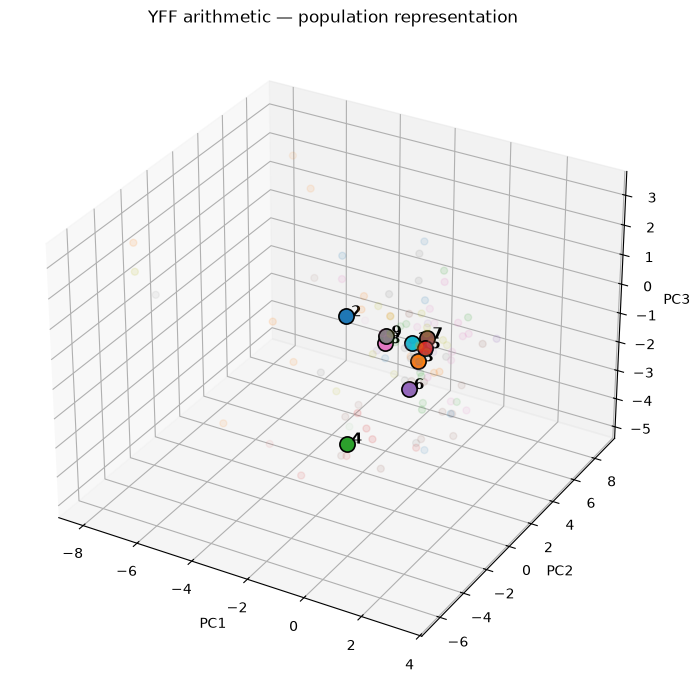

In [36]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot individual presentations
for number in numbers:

    mask = reference_labels == number
    cloud = X_pca[mask]

    ax.scatter(
        cloud[:, 0],
        cloud[:, 1],
        cloud[:, 2],
        alpha=0.35,
        s=25,
        label=str(number),
    )

# Plot and label centroids
for i, number in enumerate(numbers):

    x, y, z = pca_centroids[i]

    ax.scatter(
        x, y, z,
        s=120,
        edgecolor="black",
        linewidth=1.2,
    )

    ax.text(
        x, y, z,
        f" {number}",
        fontsize=11,
        fontweight="bold",
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("YFF arithmetic — population representation")

plt.tight_layout()
plt.show()

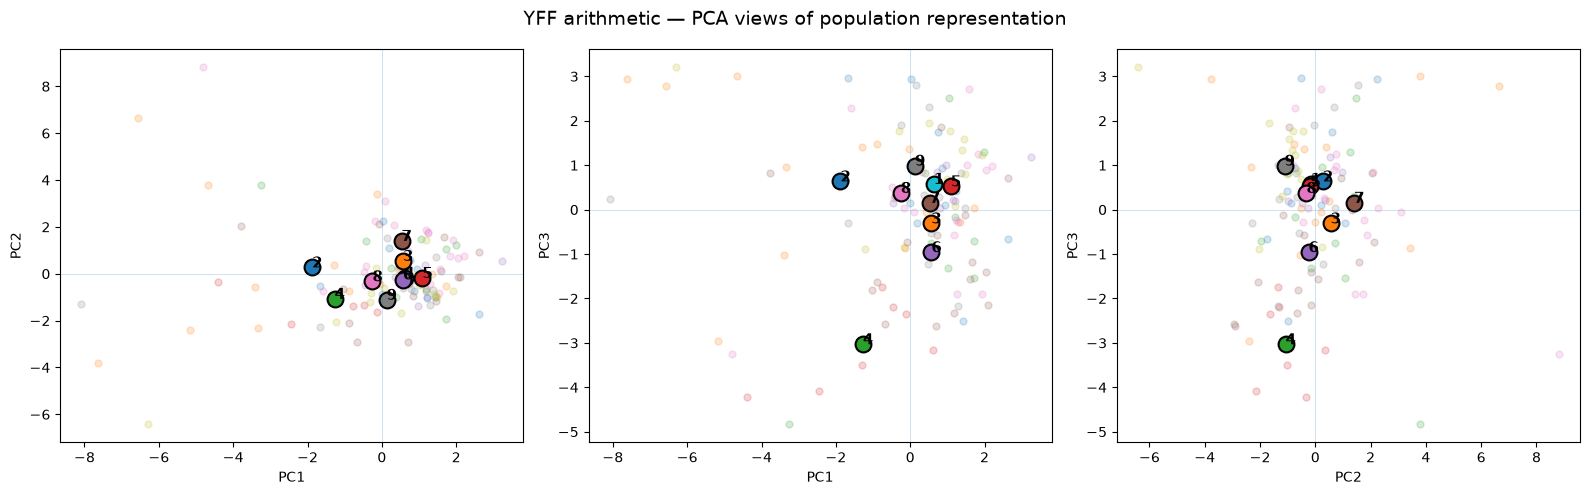

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    (0, 1, "PC1", "PC2"),
    (0, 2, "PC1", "PC3"),
    (1, 2, "PC2", "PC3"),
]

for ax, (a, b, xlabel, ylabel) in zip(axes, pairs):

    # Individual presentations
    for number in numbers:
        mask = reference_labels == number

        ax.scatter(
            X_pca[mask, a],
            X_pca[mask, b],
            alpha=0.20,
            s=25,
        )

    # Number centroids
    for i, number in enumerate(numbers):

        ax.scatter(
            pca_centroids[i, a],
            pca_centroids[i, b],
            s=130,
            edgecolor="black",
            linewidth=1.5,
        )

        ax.text(
            pca_centroids[i, a],
            pca_centroids[i, b],
            str(number),
            fontsize=11,
            fontweight="bold",
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(0, linewidth=0.5, alpha=0.3)
    ax.axvline(0, linewidth=0.5, alpha=0.3)

plt.suptitle(
    "YFF arithmetic — PCA views of population representation",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [38]:
pca_cloud_stats = {}

for number in numbers:

    mask = reference_labels == number
    cloud = X_pca[mask]

    mean = cloud.mean(axis=0)
    covariance = np.cov(cloud, rowvar=False)

    pca_cloud_stats[number] = {
        "mean": mean,
        "covariance": covariance,
        "n": len(cloud),
    }

for number in numbers:
    print(f"\nNumber {number}")
    print("n =", pca_cloud_stats[number]["n"])
    print("mean =", pca_cloud_stats[number]["mean"])
    print("covariance =")
    print(pca_cloud_stats[number]["covariance"])


Number 1
n = 10
mean = [ 0.63569868 -0.17282683  0.57925207]
covariance =
[[ 1.26149211 -0.5469008  -1.23858624]
 [-0.5469008   1.43561112  1.0153281 ]
 [-1.23858624  1.0153281   2.77889517]]

Number 2
n = 15
mean = [-1.87754682  0.27139868  0.63529285]
covariance =
[[ 9.1550603  -0.25730395 -1.71825629]
 [-0.25730395  6.88901612  1.25575792]
 [-1.71825629  1.25575792  2.66698955]]

Number 3
n = 11
mean = [ 0.56622783  0.54948958 -0.3105411 ]
covariance =
[[ 2.12225143 -1.4870978   1.74186107]
 [-1.4870978   2.37161499 -1.17579889]
 [ 1.74186107 -1.17579889  3.70936016]]

Number 4
n = 7
mean = [-1.27096369 -1.07387824 -3.03118352]
covariance =
[[ 2.8252233   0.11285548  1.14476223]
 [ 0.11285548  0.69337857 -0.15270322]
 [ 1.14476223 -0.15270322  0.93345731]]

Number 5
n = 7
mean = [ 1.09034808 -0.18196555  0.5231553 ]
covariance =
[[1.21108312 0.2865189  0.31336522]
 [0.2865189  0.71492509 0.08791565]
 [0.31336522 0.08791565 0.22277732]]

Number 6
n = 16
mean = [ 0.56864826 -0.246661

In [39]:
from mpl_toolkits.mplot3d import Axes3D

def plot_covariance_ellipsoid(
    ax,
    mean,
    covariance,
    scale=0.5,
    alpha=0.55,
):

    # Eigenvalues/eigenvectors of covariance
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    # Numerical safety
    eigenvalues = np.maximum(eigenvalues, 0)

    # Ellipsoid radii = scale × SD
    radii = scale * np.sqrt(eigenvalues)

    # Unit sphere
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 25)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack(
        [x.ravel(), y.ravel(), z.ravel()]
    )

    # Scale sphere into ellipsoid
    ellipsoid = np.diag(radii) @ sphere

    # Rotate according to covariance eigenvectors
    ellipsoid = eigenvectors @ ellipsoid

    # Move to number centroid
    ellipsoid = ellipsoid + mean[:, None]

    X = ellipsoid[0].reshape(x.shape)
    Y = ellipsoid[1].reshape(y.shape)
    Z = ellipsoid[2].reshape(z.shape)

    ax.plot_surface(
        X,
        Y,
        Z,
        alpha=alpha,
        linewidth=0,
    )

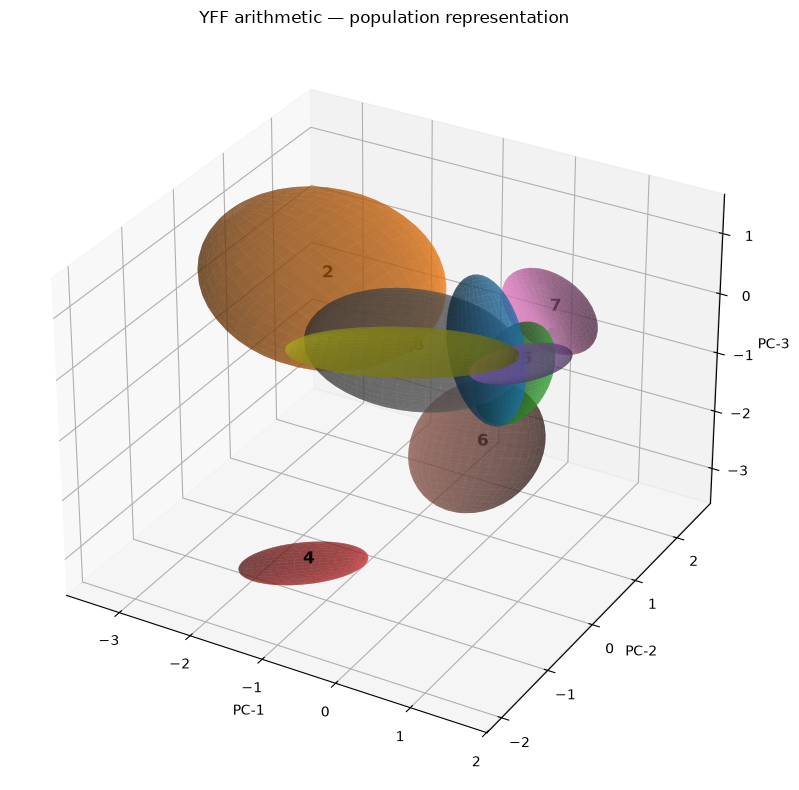

In [40]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

for number in numbers:

    stats = pca_cloud_stats[number]

    plot_covariance_ellipsoid(
        ax,
        stats["mean"],
        stats["covariance"],
        scale=0.5,
    )

    x, y, z = stats["mean"]

    ax.text(
        x,
        y,
        z,
        str(number),
        fontsize=12,
        fontweight="bold",
    )

ax.set_xlabel("PC-1")
ax.set_ylabel("PC-2")
ax.set_zlabel("PC-3")

ax.set_title(
    "YFF arithmetic — population representation"
)

plt.tight_layout()
plt.show()

In [41]:
%pip install plotly

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 7.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.7 MB 12.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.7 MB 13.2 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.7 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 12.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [43]:
import numpy as np
import plotly.graph_objects as go

# One color for each number
colors = [
    "#636EFA",  # 1
    "#EF553B",  # 2
    "#00CC96",  # 3
    "#AB63FA",  # 4
    "#FFA15A",  # 5
    "#19D3F3",  # 6
    "#FF6692",  # 7
    "#B6E880",  # 8
    "#FF97FF",  # 9
]

fig = go.Figure()

for i, number in enumerate(numbers):

    mean = pca_cloud_stats[number]["mean"]
    covariance = pca_cloud_stats[number]["covariance"]

    # --------------------------------------------------
    # 1. Eigendecomposition of covariance
    # --------------------------------------------------
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.maximum(eigenvalues, 0)

    # Paper: radius = 0.5 × within-condition SD
    radii = 0.5 * np.sqrt(eigenvalues)

    # --------------------------------------------------
    # 2. Construct unit sphere
    # --------------------------------------------------
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 30)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([
        xs.ravel(),
        ys.ravel(),
        zs.ravel()
    ])

    # --------------------------------------------------
    # 3. Transform sphere into covariance ellipsoid
    #
    # E_c(u) = μ_c + 0.5 V_c Λ_c^(1/2) u
    # --------------------------------------------------
    ellipsoid = (
        eigenvectors
        @ np.diag(radii)
        @ sphere
        + mean[:, None]
    )

    X = ellipsoid[0].reshape(xs.shape)
    Y = ellipsoid[1].reshape(ys.shape)
    Z = ellipsoid[2].reshape(zs.shape)

    # --------------------------------------------------
    # 4. Plot ellipsoid
    # --------------------------------------------------
    fig.add_trace(
        go.Surface(
            x=X,
            y=Y,
            z=Z,

            surfacecolor=np.zeros_like(X),

            colorscale=[
                [0, colors[i]],
                [1, colors[i]]
            ],

            cmin=0,
            cmax=1,

            opacity=0.65,
            showscale=False,

            name=f"Number {number}",
            hoverinfo="name",
            showlegend=False
        )
    )

    # --------------------------------------------------
    # 5. Number label at centroid
    # --------------------------------------------------
    fig.add_trace(
        go.Scatter3d(
            x=[mean[0]],
            y=[mean[1]],
            z=[mean[2]],

            mode="markers+text",

            marker=dict(
                size=5,
                color=colors[i]
            ),

            text=[str(number)],
            textposition="top center",

            textfont=dict(
                size=16,
                color=colors[i]
            ),

            name=f"Number {number}",

            hovertemplate=(
                f"<b>Number {number}</b><br>"
                f"PC1 = {mean[0]:.2f}<br>"
                f"PC2 = {mean[1]:.2f}<br>"
                f"PC3 = {mean[2]:.2f}"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(

    title=(
        "YFF arithmetic — interactive population representation"
    ),

    scene=dict(

        xaxis_title="PC-1",
        yaxis_title="PC-2",
        zaxis_title="PC-3",

        # Keep actual geometric proportions
        aspectmode="data"
    ),

    width=950,
    height=800,

    legend=dict(
        title="Number"
    )
)

fig.show()